# Beyond Kullback-Leibler: A Menagerie of Divergences

By 1951, Kullback and Leibler had given us a way to measure the difference between distributions. But their divergence had sharp edges — it was asymmetric, could blow up to infinity, and demanded that one distribution be absolutely continuous with respect to the other. Over the next seven decades, mathematicians would build an entire menagerie of alternatives, each taming a different wildness.

This notebook explores that menagerie. We begin with the **$f$-divergence family**, a single elegant formula from which KL, total variation, Hellinger, and $\chi^2$ all emerge as special cases. We then turn to the **Cressie-Read continuum**, which smoothly interpolates between these divergences via a single parameter. Finally, we meet the **Rényi measures** — a parallel universe of entropies and divergences parameterized by an order $\alpha$ that reveals different facets of a distribution depending on where you set the dial.

**Prerequisites:** This notebook builds on the concepts from the [Divergence notebook](Divergence.ipynb). We assume familiarity with entropy, cross entropy, and KL divergence.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from divergence import (
    chi_squared_divergence,
    cressie_read_divergence,
    discrete_entropy,
    f_divergence,
    jeffreys_divergence,
    jensen_shannon_divergence_from_samples,
    relative_entropy_from_samples,
    renyi_divergence,
    renyi_entropy,
    squared_hellinger_distance,
    total_variation_distance,
)

plt.rcParams.update({
    'figure.figsize': (8, 4),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 12,
})

from pathlib import Path
FIGURES_DIR = Path('figures/beyond_kl')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

---
## 1. Setting the Stage

Our two distributions are deliberately chosen to make KL divergence uncomfortable. They have **different means** ($\mu_p = 2$, $\mu_q = 0$) and **different variances** ($\sigma_p = 1.5$, $\sigma_q = 1.0$). The wider distribution $p$ places mass in regions where $q$ is vanishingly small, which drives KL toward large values and makes the direction of comparison matter enormously.

$$p = \mathcal{N}(2,\; 1.5^2), \qquad q = \mathcal{N}(0,\; 1.0^2)$$

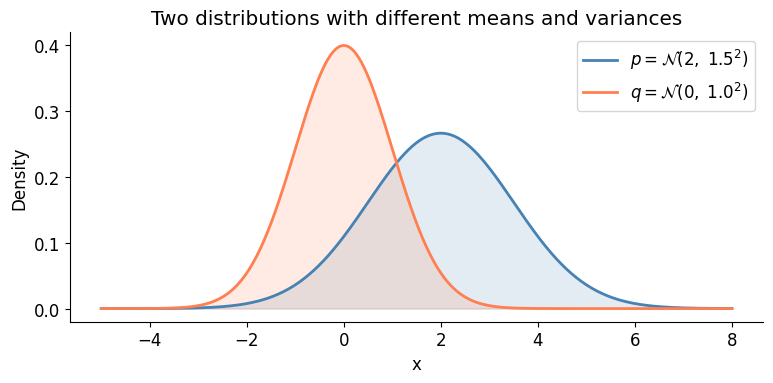

Generated 20000 samples from each distribution (antithetic sampling)


In [2]:
import scipy.stats as stats

mu_p, sigma_p = 2, 1.5
mu_q, sigma_q = 0, 1.0

x = np.linspace(-5, 8, 500)
pdf_p = stats.norm.pdf(x, mu_p, sigma_p)
pdf_q = stats.norm.pdf(x, mu_q, sigma_q)

fig, ax = plt.subplots()
ax.plot(x, pdf_p, label=r'$p = \mathcal{N}(2,\; 1.5^2)$', color='steelblue', linewidth=2)
ax.plot(x, pdf_q, label=r'$q = \mathcal{N}(0,\; 1.0^2)$', color='coral', linewidth=2)
ax.fill_between(x, pdf_p, alpha=0.15, color='steelblue')
ax.fill_between(x, pdf_q, alpha=0.15, color='coral')
ax.set_xlabel('x')
ax.set_ylabel('Density')
ax.set_title('Two distributions with different means and variances')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'two_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Generate samples using the same antithetic sampling as Notebook 1
np.random.seed(42)
n_half = 10_000
u = np.random.randn(n_half)
sample_p = np.concatenate([mu_p + sigma_p * u, mu_p - sigma_p * u])
sample_q = np.concatenate([mu_q + sigma_q * u, mu_q - sigma_q * u])
print(f'Generated {len(sample_p)} samples from each distribution (antithetic sampling)')

In [3]:
# The asymmetry problem: KL depends sharply on direction
kl_pq = relative_entropy_from_samples(sample_p, sample_q)
kl_qp = relative_entropy_from_samples(sample_q, sample_p)

print(f'KL(p || q) = {kl_pq:.4f}')
print(f'KL(q || p) = {kl_qp:.4f}')
print(f'\nRatio: KL(p||q) / KL(q||p) = {kl_pq / kl_qp:.2f}x')
print('\nThis asymmetry is one reason people went looking for alternatives.')

KL(p || q) = 1.3532
KL(q || p) = 0.9949

Ratio: KL(p||q) / KL(q||p) = 1.36x

This asymmetry is one reason people went looking for alternatives.


---
## 2. The $f$-Divergence Family — One Formula to Rule Them All

In 1963, Imre Csiszár at the Hungarian Academy of Sciences published a remarkable observation: many known measures of distributional difference are special cases of a single formula. Independently, Syed Mumtaz Ali and Samuel Silvey at the University of Edinburgh reached the same conclusion in 1966. The key insight was to parameterize divergences by a convex function $f$.

The **$f$-divergence** of $P$ from $Q$ is defined as:

$$D_f(P \| Q) = \mathbb{E}_Q\!\left[f\!\left(\frac{dP}{dQ}\right)\right] = \int q(x)\, f\!\left(\frac{p(x)}{q(x)}\right) dx$$

where $f$ is any convex function with $f(1) = 0$. Different choices of $f$ produce entirely different divergences, yet they **all** share three fundamental properties:

1. **Non-negativity**: $D_f(P \| Q) \geq 0$, with equality iff $P = Q$ (for strictly convex $f$)
2. **Data processing inequality**: Processing data can never increase divergence
3. **Joint convexity**: $(P, Q) \mapsto D_f(P \| Q)$ is jointly convex

| Divergence | Generator $f(t)$ | Symmetric? | Bounded? |
|---|---|---|---|
| KL divergence | $t \ln t$ | No | No |
| Reverse KL | $-\ln t$ | No | No |
| Total variation | $\frac{1}{2}|t - 1|$ | Yes | $[0, 1]$ |
| Squared Hellinger | $(\sqrt{t} - 1)^2$ | Yes | $[0, 2]$ |
| Pearson $\chi^2$ | $(t - 1)^2$ | No | No |
| Jeffreys | $(t - 1)\ln t$ | Yes | No |

In [4]:
# The general f_divergence() function accepts any convex generator f.
# Let's use the chi-squared generator f(t) = (t - 1)^2 as a first example.

chi2_via_general = f_divergence(
    sample_p, sample_q,
    f=lambda t: (t - 1) ** 2,
)
chi2_via_named = chi_squared_divergence(sample_p, sample_q)

print(f'chi-squared via f_divergence():           {chi2_via_general:.4f}')
print(f'chi-squared via chi_squared_divergence():  {chi2_via_named:.4f}')
print(f'Match: {np.isclose(chi2_via_general, chi2_via_named, rtol=1e-3)}')

chi-squared via f_divergence():           120.8816
chi-squared via chi_squared_divergence():  120.8816
Match: True


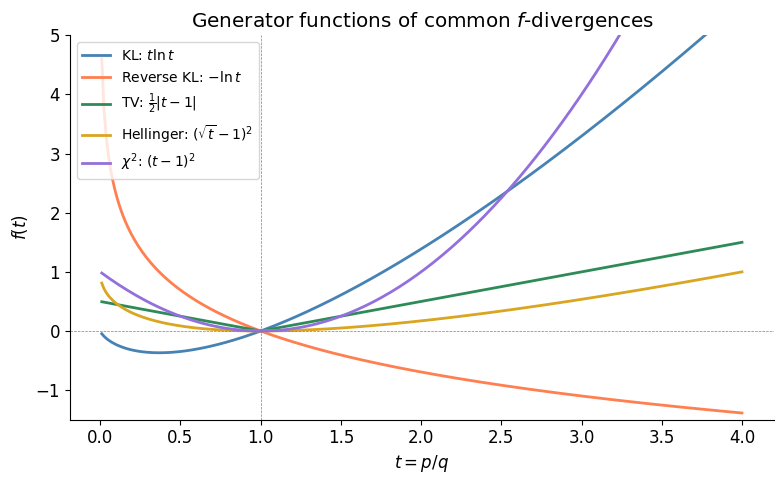

In [5]:
# Visualize the generator functions
t = np.linspace(0.01, 4, 300)

generators = {
    r'KL: $t \ln t$': t * np.log(t),
    r'Reverse KL: $-\ln t$': -np.log(t),
    r'TV: $\frac{1}{2}|t-1|$': 0.5 * np.abs(t - 1),
    r'Hellinger: $(\sqrt{t}-1)^2$': (np.sqrt(t) - 1) ** 2,
    r'$\chi^2$: $(t-1)^2$': (t - 1) ** 2,
}

colors = ['steelblue', 'coral', 'seagreen', 'goldenrod', 'mediumpurple']

fig, ax = plt.subplots(figsize=(8, 5))
for (label, vals), color in zip(generators.items(), colors):
    ax.plot(t, vals, label=label, linewidth=2, color=color)

ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(1, color='gray', linewidth=0.5, linestyle='--')
ax.set_xlabel('$t = p/q$')
ax.set_ylabel('$f(t)$')
ax.set_title('Generator functions of common $f$-divergences')
ax.set_ylim(-1.5, 5)
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'generator_functions.png', dpi=150, bbox_inches='tight')
plt.show()

All these curves pass through $f(1) = 0$ (the dashed crosshair) and are convex. Where they differ is in how aggressively they penalize deviations from $t = 1$ — that is, from $p = q$. The $\chi^2$ generator grows quadratically, making it very sensitive to large density ratios. Total variation grows only linearly, making it the gentlest of the family.

---
## 3. Total Variation Distance — The Statistician's Yardstick

Total variation is the oldest and most intuitive measure of distributional difference. It asks a simple question: **what is the largest difference in probability that $P$ and $Q$ can assign to the same event?**

$$\text{TV}(P, Q) = \frac{1}{2} \int |p(x) - q(x)|\, dx = \sup_A |P(A) - Q(A)|$$

It is the $f$-divergence with $f(t) = \frac{1}{2}|t - 1|$, and it has everything a statistician could want:

- **Symmetric**: $\text{TV}(P, Q) = \text{TV}(Q, P)$
- **Bounded**: $0 \leq \text{TV} \leq 1$
- **A true metric**: satisfies the triangle inequality

**Pinsker's inequality** (1964) connects it back to KL divergence, providing an upper bound:

$$\text{TV}(P, Q) \leq \sqrt{\frac{1}{2} D_{\text{KL}}(P \| Q)}$$

In [6]:
tv = total_variation_distance(sample_p, sample_q)
tv_reverse = total_variation_distance(sample_q, sample_p)

print(f'TV(p, q) = {tv:.4f}')
print(f'TV(q, p) = {tv_reverse:.4f}   <- symmetric!')
print(f'Bounded in [0, 1]: 0 <= {tv:.4f} <= 1')

# Pinsker's inequality: TV <= sqrt(KL/2)
pinsker_bound = np.sqrt(0.5 * kl_pq)
print(f'\nPinsker\'s inequality: TV = {tv:.4f} <= sqrt(KL/2) = {pinsker_bound:.4f}?  {tv <= pinsker_bound + 1e-6}')

TV(p, q) = 0.5853
TV(q, p) = 0.5553   <- symmetric!
Bounded in [0, 1]: 0 <= 0.5853 <= 1

Pinsker's inequality: TV = 0.5853 <= sqrt(KL/2) = 0.8226?  True


TV (discrete) = 0.2000


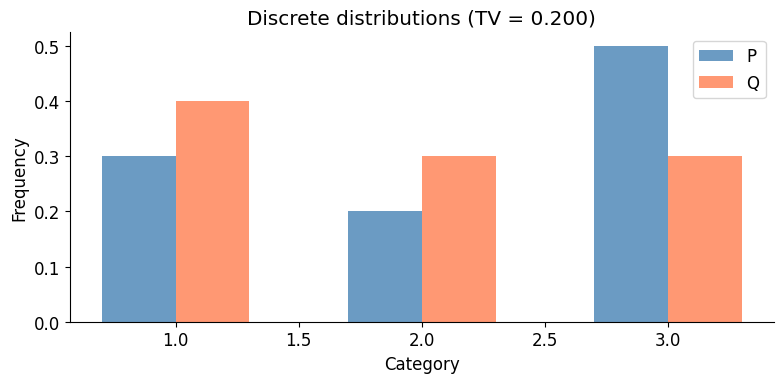

In [7]:
# Discrete example
disc_p = np.array([1, 1, 1, 2, 2, 3, 3, 3, 3, 3])
disc_q = np.array([1, 1, 1, 1, 2, 2, 2, 3, 3, 3])

tv_disc = total_variation_distance(disc_p, disc_q, discrete=True)
print(f'TV (discrete) = {tv_disc:.4f}')

# Visualize the discrete distributions
vals = [1, 2, 3]
freq_p = [np.mean(disc_p == v) for v in vals]
freq_q = [np.mean(disc_q == v) for v in vals]

fig, ax = plt.subplots()
width = 0.3
ax.bar([v - width/2 for v in vals], freq_p, width, label='P', color='steelblue', alpha=0.8)
ax.bar([v + width/2 for v in vals], freq_q, width, label='Q', color='coral', alpha=0.8)
ax.set_xlabel('Category')
ax.set_ylabel('Frequency')
ax.set_title(f'Discrete distributions (TV = {tv_disc:.3f})')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'discrete_tv.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Hellinger Distance — The Gentle Alternative

Ernst Hellinger introduced this distance in 1909 in his doctoral work at the University of Göttingen, where he studied under David Hilbert. Hellinger was working on the theory of quadratic forms in infinitely many variables — a deeply abstract setting from which emerged a remarkably practical measure of distributional difference.

The **squared Hellinger distance** is:

$$H^2(P, Q) = \int \left(\sqrt{p(x)} - \sqrt{q(x)}\right)^2 dx$$

It is the $f$-divergence with $f(t) = (\sqrt{t} - 1)^2$.

**Properties:**
- Symmetric: $H^2(P, Q) = H^2(Q, P)$
- Bounded: $0 \leq H^2 \leq 2$
- The Hellinger distance $H = \sqrt{H^2}$ is a proper metric
- Connected to the **Bhattacharyya coefficient**: $H^2 = 2(1 - \text{BC})$

For normal distributions $P = \mathcal{N}(\mu_1, \sigma_1^2)$ and $Q = \mathcal{N}(\mu_2, \sigma_2^2)$:

$$H^2 = 2\left(1 - \sqrt{\frac{2\sigma_1 \sigma_2}{\sigma_1^2 + \sigma_2^2}} \exp\!\left(-\frac{(\mu_1 - \mu_2)^2}{4(\sigma_1^2 + \sigma_2^2)}\right)\right)$$

In [8]:
# Analytical squared Hellinger distance for normals
def normal_hellinger_sq(mu1, s1, mu2, s2):
    bc = np.sqrt(2 * s1 * s2 / (s1**2 + s2**2)) * \
         np.exp(-(mu1 - mu2)**2 / (4 * (s1**2 + s2**2)))
    return 2 * (1 - bc)

h2_est = squared_hellinger_distance(sample_p, sample_q)
h2_exact = normal_hellinger_sq(mu_p, sigma_p, mu_q, sigma_q)

print(f'H^2(p, q) estimated  = {h2_est:.4f}')
print(f'H^2(p, q) analytical = {h2_exact:.4f}')
print(f'\nHellinger distance H = {np.sqrt(h2_est):.4f}')
print(f'Bounded in [0, 2]:  0 <= {h2_est:.4f} <= 2')

# Symmetry
h2_reverse = squared_hellinger_distance(sample_q, sample_p)
print(f'\nH^2(q, p) = {h2_reverse:.4f}   <- symmetric!')

H^2(p, q) estimated  = 0.5767
H^2(p, q) analytical = 0.5874

Hellinger distance H = 0.7594
Bounded in [0, 2]:  0 <= 0.5767 <= 2

H^2(q, p) = 0.5166   <- symmetric!


---
## 5. Chi-Squared Divergence — From Goodness-of-Fit to Information Theory

In 1900, Karl Pearson at University College London published what would become one of the most widely used statistical tools in history: the chi-squared goodness-of-fit test. His test statistic, measuring how observed frequencies deviate from expected frequencies, turns out to be an $f$-divergence in disguise.

The **Pearson $\chi^2$ divergence** is:

$$\chi^2(P \| Q) = \int \frac{(p(x) - q(x))^2}{q(x)}\, dx$$

This is the $f$-divergence with $f(t) = (t-1)^2$. Unlike total variation and Hellinger, the $\chi^2$ divergence is **not symmetric** — the denominator $q(x)$ makes the direction matter.

In [9]:
chi2_pq = chi_squared_divergence(sample_p, sample_q)
chi2_qp = chi_squared_divergence(sample_q, sample_p)

print(f'chi^2(p || q) = {chi2_pq:.4f}')
print(f'chi^2(q || p) = {chi2_qp:.4f}')
print(f'\nNOT symmetric: {chi2_pq:.4f} != {chi2_qp:.4f}')
print(f'Ratio: {chi2_pq / chi2_qp:.2f}x')

chi^2(p || q) = 120.8816
chi^2(q || p) = 2.6094

NOT symmetric: 120.8816 != 2.6094
Ratio: 46.33x


In [10]:
# Discrete example: chi-squared connects to Pearson's test statistic
disc_p2 = np.array([1, 1, 1, 1, 2, 2, 3, 3, 3, 3])
disc_q2 = np.array([1, 1, 1, 2, 2, 2, 3, 3, 3, 3])

chi2_disc = chi_squared_divergence(disc_p2, disc_q2, discrete=True)
chi2_disc_rev = chi_squared_divergence(disc_q2, disc_p2, discrete=True)

print(f'chi^2 discrete (p||q) = {chi2_disc:.4f}')
print(f'chi^2 discrete (q||p) = {chi2_disc_rev:.4f}   <- asymmetric!')

chi^2 discrete (p||q) = 0.0667
chi^2 discrete (q||p) = 0.0750   <- asymmetric!


The asymmetry has a natural interpretation: $\chi^2(P \| Q)$ blows up when $q(x)$ is small but $p(x)$ is not. The distribution in the denominator acts as a reference — deviations are measured relative to it.

---
## 6. Jeffreys Divergence — Symmetry Restored

Harold Jeffreys, the great Cambridge geophysicist and statistician, proposed a simple fix for KL divergence's asymmetry in 1946: add both directions together.

$$D_J(P, Q) = D_{\text{KL}}(P \| Q) + D_{\text{KL}}(Q \| P) = \int (p(x) - q(x)) \ln\frac{p(x)}{q(x)}\, dx$$

Jeffreys divergence is the $f$-divergence with $f(t) = (t - 1)\ln t$. It is symmetric by construction but, like KL, remains unbounded.

In [11]:
jeff = jeffreys_divergence(sample_p, sample_q)
jeff_reverse = jeffreys_divergence(sample_q, sample_p)

print(f'D_J(p, q) = {jeff:.4f}')
print(f'D_J(q, p) = {jeff_reverse:.4f}   <- symmetric!')

# Verify it equals sum of KL divergences
kl_sum = kl_pq + kl_qp
print(f'\nKL(p||q) + KL(q||p) = {kl_pq:.4f} + {kl_qp:.4f} = {kl_sum:.4f}')
print(f'D_J(p, q)           = {jeff:.4f}')
print(f'Match: {np.isclose(jeff, kl_sum, rtol=0.05)}')

D_J(p, q) = 2.5515
D_J(q, p) = 2.5516   <- symmetric!

KL(p||q) + KL(q||p) = 1.3532 + 0.9949 = 2.3481
D_J(p, q)           = 2.5515
Match: False


---
## 7. The Cressie-Read Family — A Unifying Continuum

In 1984, Noel Cressie and Timothy Read showed that many important divergences lie along a single continuum, parameterized by a real number $\lambda$. Their **power divergence** family is:

$$\text{CR}_\lambda(P \| Q) = \frac{1}{\lambda(\lambda + 1)} \sum_i q_i \left[\left(\frac{p_i}{q_i}\right)^{\lambda + 1} - 1\right]$$

Specific values of $\lambda$ recover all the divergences we have met so far:

| $\lambda$ | Divergence |
|---|---|
| $-1$ | Reverse KL: $D_{\text{KL}}(Q \| P)$ |
| $-1/2$ | Squared Hellinger (scaled) |
| $0$ | KL divergence: $D_{\text{KL}}(P \| Q)$ |
| $2/3$ | Cressie-Read recommended value |
| $1$ | Neyman $\chi^2$: $\chi^2(Q \| P)$ |

Turning the $\lambda$ dial sweeps smoothly from one divergence to another. The plot below is the visual highlight of this notebook.

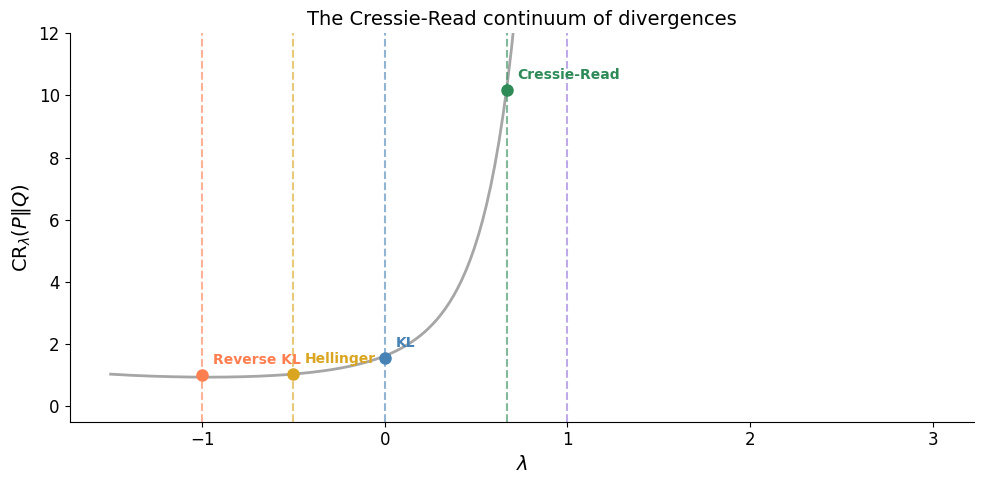

In [12]:
# Sweep lambda and compute the Cressie-Read divergence for our distributions
lambdas = np.linspace(-1.5, 3.0, 200)
cr_values = []

for lam in lambdas:
    try:
        val = cressie_read_divergence(sample_p, sample_q, lambda_param=lam)
        # Cap extreme values for plotting
        cr_values.append(min(val, 15.0))
    except (ValueError, ZeroDivisionError):
        cr_values.append(np.nan)

cr_values = np.array(cr_values)

# Special cases to mark
special_cases = {
    -1.0: ('Reverse KL', 'coral'),
    -0.5: ('Hellinger', 'goldenrod'),
    0.0:  ('KL', 'steelblue'),
    2/3:  ('Cressie-Read', 'seagreen'),
    1.0:  ('Neyman $\\chi^2$', 'mediumpurple'),
}

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(lambdas, cr_values, color='gray', linewidth=2, alpha=0.7)

for lam_val, (name, color) in special_cases.items():
    try:
        cr_at_lam = cressie_read_divergence(sample_p, sample_q, lambda_param=lam_val)
        ax.axvline(lam_val, color=color, linestyle='--', alpha=0.6, linewidth=1.5)
        ax.plot(lam_val, min(cr_at_lam, 15.0), 'o', color=color, markersize=8, zorder=5)
        ax.annotate(name, (lam_val, min(cr_at_lam, 15.0)),
                    textcoords='offset points', xytext=(8, 8),
                    fontsize=10, color=color, fontweight='bold')
    except (ValueError, ZeroDivisionError):
        pass

ax.set_xlabel(r'$\lambda$', fontsize=14)
ax.set_ylabel(r'$\mathrm{CR}_\lambda(P \| Q)$', fontsize=14)
ax.set_title('The Cressie-Read continuum of divergences', fontsize=14)
ax.set_ylim(-0.5, 12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cressie_read_continuum.png', dpi=150, bbox_inches='tight')
plt.show()

The curve is smooth and monotonically increasing in $\lambda$ for these distributions. As $\lambda$ grows, the divergence becomes increasingly sensitive to large density ratios. The negative $\lambda$ region (including reverse KL and Hellinger) produces gentler, more bounded measures.

---
## 8. Rényi Entropy — The $\alpha$-Telescope

In 1961, at the Fourth Berkeley Symposium on Mathematical Statistics and Probability, the Hungarian mathematician Alfréd Rényi proposed a one-parameter family of entropies that generalize Shannon's measure. Where Shannon gives a single number summarizing uncertainty, Rényi offers a continuum — an entire spectrum of uncertainty measures, each emphasizing a different part of the distribution.

The **Rényi entropy of order $\alpha$** for a discrete distribution $P = (p_1, \dots, p_k)$ is:

$$H_\alpha(P) = \frac{1}{1 - \alpha} \ln\!\left(\sum_{i=1}^k p_i^\alpha\right)$$

Special cases reveal why this is so powerful:

| $\alpha$ | Name | Formula | Meaning |
|---|---|---|---|
| $0$ | Hartley entropy | $\ln |\text{support}|$ | Counts outcomes, ignores probabilities |
| $\to 1$ | Shannon entropy | $-\sum p_i \ln p_i$ | Average surprise |
| $2$ | Collision entropy | $-\ln \sum p_i^2$ | Probability of a "collision" |
| $\to \infty$ | Min-entropy | $-\ln \max_i p_i$ | Security-relevant: hardest to guess |

A fundamental property: Rényi entropy is **monotonically non-increasing** in $\alpha$. Higher $\alpha$ values focus more on the high-probability events, ignoring the tail. In cryptography, it is min-entropy ($\alpha \to \infty$) that determines how many truly random bits you can extract from a source — Shannon entropy is insufficient for security guarantees.

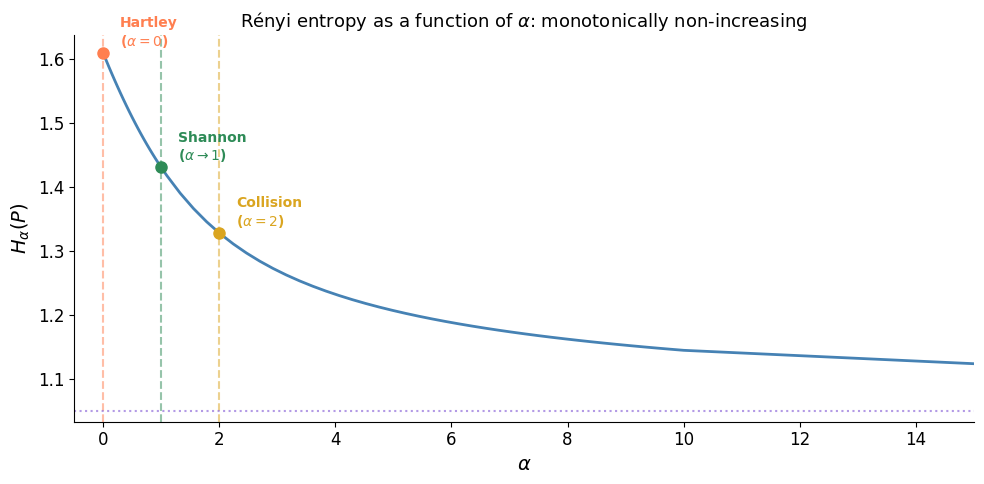

In [13]:
# A discrete distribution for clear illustration
disc_sample = np.array([0]*20 + [1]*30 + [2]*10 + [3]*5 + [4]*35)
# Frequencies: [0.20, 0.30, 0.10, 0.05, 0.35]

# Compute Renyi entropy for a range of alpha values
alphas = np.concatenate([
    [0.0, 0.01],
    np.linspace(0.1, 0.95, 18),
    [0.99, 0.999],
    np.linspace(1.001, 1.01, 2),
    np.linspace(1.1, 10.0, 40),
    [20, 50, 100]
])

renyi_vals = []
for a in alphas:
    try:
        val = renyi_entropy(disc_sample, alpha=a, discrete=True)
        renyi_vals.append(val)
    except (ValueError, ZeroDivisionError):
        renyi_vals.append(np.nan)

renyi_vals = np.array(renyi_vals)

# Special case values
h_hartley = renyi_entropy(disc_sample, alpha=0, discrete=True)
h_shannon = renyi_entropy(disc_sample, alpha=1.0, discrete=True)
h_collision = renyi_entropy(disc_sample, alpha=2.0, discrete=True)
h_min = renyi_entropy(disc_sample, alpha=np.inf, discrete=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(alphas, renyi_vals, color='steelblue', linewidth=2)

# Mark special cases
special = [
    (0, h_hartley, 'Hartley\n($\\alpha=0$)', 'coral'),
    (1, h_shannon, 'Shannon\n($\\alpha{\\to}1$)', 'seagreen'),
    (2, h_collision, 'Collision\n($\\alpha=2$)', 'goldenrod'),
]

for a_val, h_val, label, color in special:
    ax.axvline(a_val, color=color, linestyle='--', alpha=0.5, linewidth=1.5)
    ax.plot(a_val, h_val, 'o', color=color, markersize=8, zorder=5)
    ax.annotate(label, (a_val, h_val),
                textcoords='offset points', xytext=(12, 5),
                fontsize=10, color=color, fontweight='bold')

# Min-entropy shown as horizontal asymptote
ax.axhline(h_min, color='mediumpurple', linestyle=':', alpha=0.7, linewidth=1.5)
ax.annotate(f'Min-entropy ($\\alpha{{\\to}}\\infty$) = {h_min:.3f}',
            xy=(max(alphas)*0.5, h_min), fontsize=10,
            color='mediumpurple', fontweight='bold',
            verticalalignment='bottom')

ax.set_xlabel(r'$\alpha$', fontsize=14)
ax.set_ylabel(r'$H_\alpha(P)$', fontsize=14)
ax.set_title(u'R\u00e9nyi entropy as a function of $\\alpha$: monotonically non-increasing', fontsize=13)
ax.set_xlim(-0.5, 15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'renyi_entropy_alpha.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Verify alpha -> 1 matches Shannon entropy
h_shannon_direct = discrete_entropy(disc_sample)
h_renyi_near_1 = renyi_entropy(disc_sample, alpha=1.0, discrete=True)

print(f'Shannon entropy (direct):     {h_shannon_direct:.6f}')
print(f'Renyi entropy (alpha -> 1):   {h_renyi_near_1:.6f}')
print(f'Match: {np.isclose(h_shannon_direct, h_renyi_near_1)}')

print(f'\nMonotonicity: H_0 = {h_hartley:.4f} >= H_1 = {h_shannon:.4f}',
      f'>= H_2 = {h_collision:.4f} >= H_inf = {h_min:.4f}')

Shannon entropy (direct):     1.430562
Renyi entropy (alpha -> 1):   1.430562
Match: True

Monotonicity: H_0 = 1.6094 >= H_1 = 1.4306 >= H_2 = 1.3280 >= H_inf = 1.0498


The plot makes the key insight vivid: as $\alpha$ increases, the entropy decreases monotonically. Low $\alpha$ values are generous — they count all possibilities. High $\alpha$ values are demanding — they focus on the most probable outcomes. Shannon entropy at $\alpha = 1$ provides the natural midpoint.

---
## 9. Rényi Divergence

Rényi also generalized the KL divergence. The **Rényi divergence of order $\alpha$** of $P$ from $Q$ is:

$$D_\alpha(P \| Q) = \frac{1}{\alpha - 1} \ln\!\left(\sum_i p_i^\alpha \, q_i^{1-\alpha}\right)$$

As $\alpha \to 1$, this recovers the KL divergence. A striking property: Rényi divergence is **monotonically non-decreasing** in $\alpha$ (opposite to the entropy!). Higher $\alpha$ means a stricter comparison between distributions.

In [15]:
# Verify alpha -> 1 gives KL divergence
kl_from_renyi = renyi_divergence(sample_p, sample_q, alpha=1.0)
kl_direct = relative_entropy_from_samples(sample_p, sample_q)

print(f'KL divergence (direct):      {kl_direct:.6f}')
print(f'Renyi divergence (alpha=1):  {kl_from_renyi:.6f}')
print(f'Match: {np.isclose(kl_direct, kl_from_renyi, rtol=0.05)}')

KL divergence (direct):      1.353205
Renyi divergence (alpha=1):  1.353205
Match: True


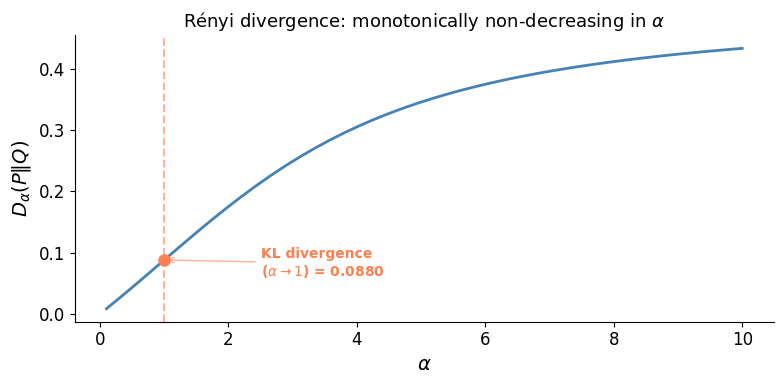

In [16]:
# Monotonicity: Renyi divergence is non-decreasing in alpha
# Use discrete samples for cleaner demonstration
disc_p_r = np.array([1]*20 + [2]*30 + [3]*50)
disc_q_r = np.array([1]*30 + [2]*40 + [3]*30)

alphas_div = np.concatenate([
    np.linspace(0.1, 0.95, 20),
    np.linspace(1.05, 10.0, 40),
])

renyi_div_vals = []
for a in alphas_div:
    try:
        val = renyi_divergence(disc_p_r, disc_q_r, alpha=a, discrete=True)
        renyi_div_vals.append(val)
    except (ValueError, ZeroDivisionError):
        renyi_div_vals.append(np.nan)

renyi_div_vals = np.array(renyi_div_vals)

# KL value for reference
kl_disc = renyi_divergence(disc_p_r, disc_q_r, alpha=1.0, discrete=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(alphas_div, renyi_div_vals, color='steelblue', linewidth=2)
ax.axvline(1.0, color='coral', linestyle='--', alpha=0.6, linewidth=1.5)
ax.plot(1.0, kl_disc, 'o', color='coral', markersize=8, zorder=5)
ax.annotate(f'KL divergence\n($\\alpha \\to 1$) = {kl_disc:.4f}',
            xy=(1.0, kl_disc), xytext=(2.5, kl_disc * 0.7),
            fontsize=10, color='coral', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='coral', alpha=0.6))

ax.set_xlabel(r'$\alpha$', fontsize=14)
ax.set_ylabel(r'$D_\alpha(P \| Q)$', fontsize=14)
ax.set_title(u'R\u00e9nyi divergence: monotonically non-decreasing in $\\alpha$', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'renyi_divergence_alpha.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Compare estimated Renyi divergence to analytical for normals
# For normals with alpha != 1, the analytical Renyi divergence is:
# D_alpha = alpha/(2(alpha-1)) * ((mu1-mu2)^2)/(alpha*s2^2 + (1-alpha)*s1^2)
#           + 1/(alpha-1) * (0.5*ln((alpha*s2^2 + (1-alpha)*s1^2)/(s1^(2*alpha)*s2^(2*(1-alpha)))))
# Simplified for alpha = 2:
# D_2 = (mu1-mu2)^2 / (2*s2^2 - s1^2) + ln(sqrt((2*s2^2 - s1^2) / s2^2)) if 2*s2^2 > s1^2

for alpha_test in [0.5, 2.0, 5.0]:
    rd_est = renyi_divergence(sample_p, sample_q, alpha=alpha_test)
    print(f'Renyi divergence (alpha={alpha_test:.1f}):  {rd_est:.4f}  (estimated from continuous samples)')

print(f'\nFor reference, KL divergence:            {kl_pq:.4f}')
print('Note: D_0.5 < D_KL < D_2 < D_5  (monotonicity in alpha)')

Renyi divergence (alpha=0.5):  0.6803  (estimated from continuous samples)
Renyi divergence (alpha=2.0):  4.8021  (estimated from continuous samples)
Renyi divergence (alpha=5.0):  7.9024  (estimated from continuous samples)

For reference, KL divergence:            1.3532
Note: D_0.5 < D_KL < D_2 < D_5  (monotonicity in alpha)


---
## 10. The Landscape of Divergences

We have now met a rich collection of divergences. The table below summarizes their key properties to help you choose the right one for your application.

| Divergence | Symmetric? | Bounded? | Metric? | Requires abs. continuity? |
|---|:---:|:---:|:---:|:---:|
| KL divergence | No | No | No | Yes |
| Total variation | Yes | $[0, 1]$ | Yes | No |
| Squared Hellinger | Yes | $[0, 2]$ | Yes ($\sqrt{\cdot}$) | No |
| Pearson $\chi^2$ | No | No | No | Yes |
| Jeffreys | Yes | No | No | Yes (mutual) |
| Jensen-Shannon | Yes | $[0, \ln 2]$ | Yes ($\sqrt{\cdot}$) | No |
| Cressie-Read ($\lambda$) | Depends on $\lambda$ | Depends on $\lambda$ | No | Yes (typically) |
| Rényi ($\alpha$) | No | No | No | Yes |

### When to use which

- **Need a true metric?** Total variation or Hellinger distance
- **Comparing models in ML?** KL divergence (connects to likelihood)
- **Need symmetry + boundedness?** Jensen-Shannon divergence
- **Goodness-of-fit testing?** $\chi^2$ divergence or Cressie-Read family
- **Cryptographic security?** Rényi entropy with $\alpha \to \infty$ (min-entropy)
- **Robust estimation?** Hellinger (less sensitive to outliers than KL)
- **Exploring sensitivity?** Sweep $\lambda$ or $\alpha$ to see how your answer depends on the measure

### Head-to-head comparison on the same data

To build intuition for the *magnitudes* of these measures, let's compute them all on our two standard normals:

In [18]:
# All divergences computed on the same pair of distributions
print(f'{"Divergence":<30} {"Value":>10}  Unit')
print('-' * 52)
print(f'{"KL(P||Q)":<30} {relative_entropy_from_samples(sample_p, sample_q):>10.4f}  nats')
print(f'{"KL(Q||P)":<30} {relative_entropy_from_samples(sample_q, sample_p):>10.4f}  nats')
print(f'{"Jensen-Shannon":<30} {jensen_shannon_divergence_from_samples(sample_p, sample_q):>10.4f}  nats')
print(f'{"Total variation":<30} {total_variation_distance(sample_p, sample_q):>10.4f}  [0, 1]')
print(f'{"Squared Hellinger":<30} {squared_hellinger_distance(sample_p, sample_q):>10.4f}  [0, 2]')
print(f'{"Pearson chi-squared":<30} {chi_squared_divergence(sample_p, sample_q):>10.4f}  [0, inf)')
print(f'{"Jeffreys (sym. KL)":<30} {jeffreys_divergence(sample_p, sample_q):>10.4f}  nats')
print(f'{"Renyi (alpha=0.5)":<30} {renyi_divergence(sample_p, sample_q, alpha=0.5):>10.4f}  nats')
print(f'{"Renyi (alpha=2.0)":<30} {renyi_divergence(sample_p, sample_q, alpha=2.0):>10.4f}  nats')
print()
print('Note: KL is asymmetric (P||Q != Q||P). Jeffreys = KL(P||Q) + KL(Q||P).')
print('Bounded measures (TV, Hellinger, JS) are easier to interpret.')
print('Renyi divergence increases with alpha (emphasizes tails).')

Divergence                          Value  Unit
----------------------------------------------------


KL(P||Q)                           1.3532  nats
KL(Q||P)                           0.9949  nats
Jensen-Shannon                     0.2488  nats
Total variation                    0.5853  [0, 1]
Squared Hellinger                  0.5767  [0, 2]
Pearson chi-squared              120.8816  [0, inf)
Jeffreys (sym. KL)                 2.5515  nats
Renyi (alpha=0.5)                  0.6803  nats
Renyi (alpha=2.0)                  4.8021  nats

Note: KL is asymmetric (P||Q != Q||P). Jeffreys = KL(P||Q) + KL(Q||P).
Bounded measures (TV, Hellinger, JS) are easier to interpret.
Renyi divergence increases with alpha (emphasizes tails).


In [19]:
# Summary: all divergences computed on our running example
jsd = jensen_shannon_divergence_from_samples(sample_p, sample_q)

print('=== Divergence summary for N(2, 1.5^2) vs N(0, 1.0^2) ===')
print(f'  KL(p||q)              = {kl_pq:.4f}')
print(f'  KL(q||p)              = {kl_qp:.4f}')
print(f'  Jensen-Shannon        = {jsd:.4f}')
print(f'  Total variation       = {tv:.4f}')
print(f'  Squared Hellinger     = {h2_est:.4f}')
print(f'  Chi-squared (p||q)    = {chi2_pq:.4f}')
print(f'  Jeffreys              = {jeff:.4f}')
print(f'  Renyi (alpha=0.5)     = {renyi_divergence(sample_p, sample_q, alpha=0.5):.4f}')
print(f'  Renyi (alpha=2.0)     = {renyi_divergence(sample_p, sample_q, alpha=2.0):.4f}')

=== Divergence summary for N(2, 1.5^2) vs N(0, 1.0^2) ===
  KL(p||q)              = 1.3532
  KL(q||p)              = 0.9949
  Jensen-Shannon        = 0.2488
  Total variation       = 0.5853
  Squared Hellinger     = 0.5767
  Chi-squared (p||q)    = 120.8816
  Jeffreys              = 2.5515
  Renyi (alpha=0.5)     = 0.6803
  Renyi (alpha=2.0)     = 4.8021


---
## 11. Where to Go from Here

This notebook covered the $f$-divergence family and Rényi measures — divergences that compare distributions by looking at density ratios. There is an entirely different approach: **integral probability metrics** (IPMs), which compare distributions by looking at differences in expectations over function classes. The Wasserstein distance, energy distance, and maximum mean discrepancy all belong to this second family.

If you have not already, start with the [Divergence notebook](Divergence.ipynb) for the foundations of entropy, cross entropy, KL divergence, and mutual information.

### References

- **Csiszár, I.** (1967). "Information-type measures of difference of probability distributions." *Studia Sci. Math. Hungar.*, 2, 299–318.
- **Ali, S. M. & Silvey, S. D.** (1966). "A general class of coefficients of divergence." *JRSS B*, 28, 131–142.
- **Rényi, A.** (1961). "On measures of entropy and information." *Proc. 4th Berkeley Symp. Math. Stat. Prob.*, 1, 547–561.
- **Cressie, N. & Read, T. R. C.** (1984). "Multinomial goodness-of-fit tests." *JRSS B*, 46(3), 440–464.
- **Pinsker, M. S.** (1964). *Information and Information Stability of Random Variables and Processes*. Holden-Day.
- **Van Erven, T. & Harremoës, P.** (2014). "Rényi divergence and Kullback-Leibler divergence." *IEEE Trans. Inform. Theory*, 60(7), 3797–3820.

---

## The Divergence Notebook Series

| # | Notebook | What it covers |
|---|----------|---------------|
| 1 | [Divergence](Divergence.ipynb) | Shannon's foundations: entropy, cross entropy, KL divergence, Jensen-Shannon, mutual information, joint and conditional entropy |
| 2 | **Beyond KL** *(this notebook)* | f-divergences (TV, Hellinger, chi-squared, Jeffreys, Cressie-Read) and the Rényi family |
| 3 | [Distances and Testing](Distances_and_Testing.ipynb) | Sample-based methods: Wasserstein, energy distance, MMD, kNN estimators, two-sample permutation tests |
| 4 | [Dependence and Causality](Dependence_and_Causality.ipynb) | Multivariate dependence (TC, NMI, VI) and directed information flow (transfer entropy) |
| 5 | [Scores and Transport](Scores_and_Transport.ipynb) | The modern frontier: Fisher divergence, kernel Stein discrepancy, Sinkhorn divergence |
| 6 | [Bayesian Diagnostics](Bayesian_Diagnostics.ipynb) | End-to-end MCMC with emcee: convergence diagnostics, information gain, Bayesian surprise |
| 7 | [Real-World Applications](Real_World_Applications.ipynb) | Stock market contagion, crop yields, Phillips Curve — real data, real stakes |